In [8]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, fbeta_score,
)
import math

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

## Model: Logistic Regression from scratch

In [2]:
def sigmoid(x):
    x = np.clip(x, -500, 500)  # To guard np.exp against overflow
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b, reg_param):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_dw += (reg_param / m) * w
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b, reg_param):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
        regularisation_term = (reg_param / (2*m)) * np.sum(w**2)
        return cost.mean() + regularisation_term

def gradient_descent(X, y, w_in, b_in, alpha, iterations, reg_param=0, show=True):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b, reg_param)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b, reg_param)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0 and show:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

## Prediction & Evaluation helpers

In [13]:
def predict_proba(X, w, b):
    return sigmoid(X @ w + b)


def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)


def best_threshold_youden(X_cv, y_cv, w, b):
    """Threshold that maximises TPR - FPR (Youden's J) on the CV set."""
    fpr, tpr, thresholds = roc_curve(y_cv, predict_proba(X_cv, w, b))
    return thresholds[np.argmax(tpr - fpr)]


def evaluate(X, y, w, b, threshold=0.5, title=""):
    """Print report + F2, show confusion matrix. Returns the predictions."""
    preds = predict(X, w, b, threshold)
    print(f"--- {title} (threshold={threshold:.3f}) ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=["normal", "anomaly"]))
    print(f"F2-score: {fbeta_score(y, preds, beta=2):.4f}\n")
    cm = confusion_matrix(y, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["normal", "anomaly"]).plot()
    plt.title(title)
    #return preds

## Scaling
Per-feature: log1p for the heavy-tailed byte columns (4, 5), standardise the rest.

In [4]:
# Scaling
# Per-feature: log1p for the heavy-tailed byte columns (4, 5), standardise the rest.
# Scaler is FITTED ON TRAIN ONLY to be reused on test

def fit_scaler(X):
    mean = X.mean(axis=0)
    std  = np.clip(X.std(axis=0), 1e-7, None)
    return mean, std

def apply_scaler(X, mean, std):
    # sorry for magic numbers
    # items 4 and 5 are source and destination bytes
    scaled = X.copy()
    scaled[:, :4] = (X[:, :4] - mean[:4]) / std[:4]
    scaled[:, 4:6] = np.log1p(X[:, 4:6])
    scaled[:, 6:] = (X[:, 6:] - mean[6:]) / std[6:]
    return scaled

## Load & Encode NSL-KDD data
LabelEncoder fitted on train, applied to test. Unseen test categories encoded as -1.

In [5]:
train_data, _ = arff.loadarff('KDDTrain+.arff')
test_data, _ = arff.loadarff('KDDTest+.arff')
df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
        test_df[col] = test_df[col].str.decode('utf-8')

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(df[col])
    df[col] = le.transform(df[col])
    known = set(le.classes_)
    test_df[col] = test_df[col].map(
        lambda v: le.transform([v])[0] if v in known else -1
    )

cats = ['normal', 'anomaly']  # index 0 = normal, index 1 = anomaly
df['class']      = pd.Categorical(df['class'], categories=cats).codes
test_df['class'] = pd.Categorical(test_df['class'], categories=cats).codes

train_X = df.iloc[:, :41].to_numpy(dtype=float)
train_y = df.iloc[:, 41].to_numpy(dtype=float)
test_X = test_df.iloc[:, :41].to_numpy(dtype=float)
test_y = test_df.iloc[:, 41].to_numpy(dtype=float)

mean, std = fit_scaler(train_X)
scaled_train_X = apply_scaler(train_X, mean, std)
scaled_test_X  = apply_scaler(test_X, mean, std)

# Take 20% of training set to form cross validation set
scaled_train_X, cv_X, train_y, cv_y = train_test_split(
    scaled_train_X, train_y, test_size=0.2, stratify=train_y, random_state=0
)

In [6]:
# init weights and biases...
w_in = np.random.random_sample(train_X[0].shape)
b_in = np.random.random_sample()
alpha = 0.1
iters = 700

## Regularisation hyperparameter-tuning
Compare train vs CV loss for varying regularisation parameter values.

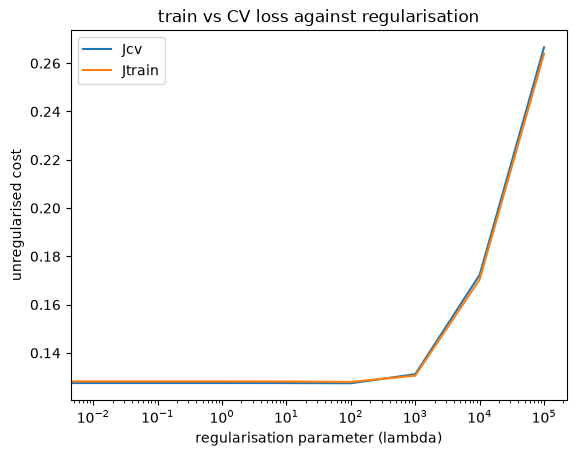

Optimal lambda = 100


In [10]:
# Use cross validation set to find optimal regularisation parameter out of a small set
lambdas = [0, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
Jcv_history = []
Jtrain_history = []
for l in lambdas:
    w, b, _ = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters, l, show=False)
    Jtrain_history.append(cost(scaled_train_X, train_y, w, b, 0))
    Jcv_history.append(cost(cv_X, cv_y, w, b, 0))

plt.plot(lambdas, Jcv_history, label='Jcv')
plt.plot(lambdas, Jtrain_history, label='Jtrain')
plt.xscale('log')
plt.xlabel("regularisation parameter (lambda)")
plt.ylabel("unregularised cost")
plt.title("train vs CV loss against regularisation")
plt.legend()
plt.show()

best_lambda = lambdas[int(np.argmin(Jcv_history))]
print(f"Optimal lambda = {best_lambda}")

## Final model + test eval
Threshold chosed on CV via Youden's J.
LAMBDA chosen from previous cell

Iteration    0: Cost 1.442767833072434
Iteration   70: Cost 0.22652088550020727
Iteration  140: Cost 0.1927071154624461
Iteration  210: Cost 0.17216645232686584
Iteration  280: Cost 0.1597088832193555
Iteration  350: Cost 0.15110101907997991
Iteration  420: Cost 0.1447778391809242
Iteration  490: Cost 0.13993572231847787
Iteration  560: Cost 0.13661783356628937
Iteration  630: Cost 0.13450022739041353


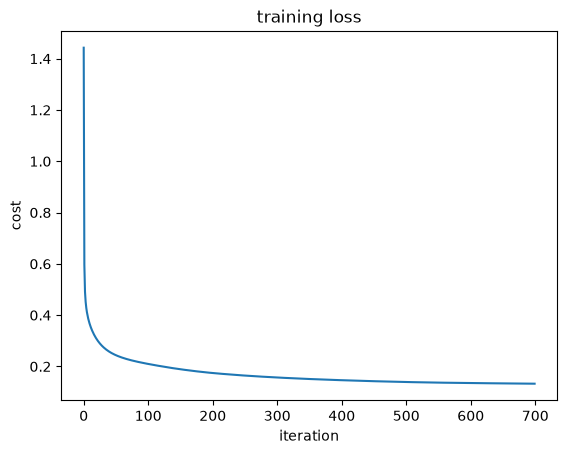

Youden's J threshold: 0.437
--- TRAIN {thr=0.5} (threshold=0.500) ---
accuracy: 0.9572
              precision    recall  f1-score   support

      normal       0.95      0.97      0.96     53874
     anomaly       0.96      0.95      0.95     46904

    accuracy                           0.96    100778
   macro avg       0.96      0.96      0.96    100778
weighted avg       0.96      0.96      0.96    100778

F2-score: 0.9488

--- TEST {thr=Youden's J} (threshold=0.437) ---
accuracy: 0.7636
              precision    recall  f1-score   support

      normal       0.66      0.93      0.77      9711
     anomaly       0.92      0.64      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.76     22544

F2-score: 0.6797



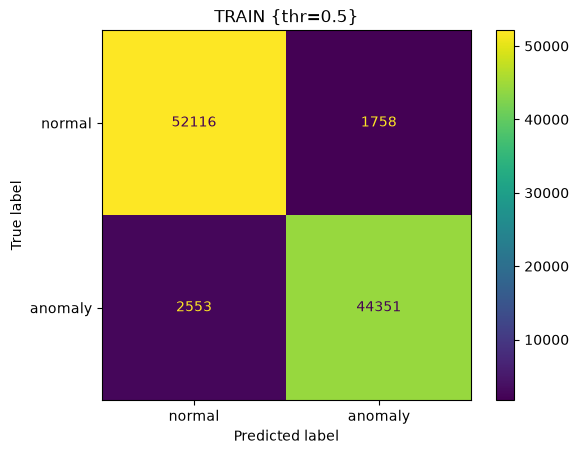

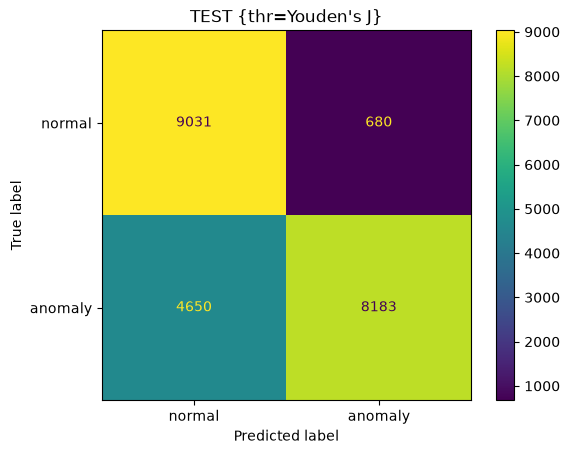

In [14]:
LAMBDA = 100
w, b, J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in,
                                   alpha, iters, LAMBDA, show=True)
plt.plot(J_history)
plt.xlabel("iteration"); plt.ylabel("cost"); plt.title("training loss"); plt.show()

thr = best_threshold_youden(cv_X, cv_y, w, b)
print(f"Youden's J threshold: {thr:.3f}")

evaluate(scaled_train_X, train_y, w, b, threshold=0.5, title="TRAIN {thr=0.5}")
evaluate(scaled_test_X, test_y, w, b, threshold=thr, title="TEST {thr=Youden's J}")